In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
##Dataset Shape
df.shape

(891, 12)

In [6]:
##Identify Missing Values
##The following code checks the number of missing values in each column.
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
## Step 6: Check Duplicate Rows
## This identifies duplicate records in the dataset.
df.duplicated().sum()

np.int64(0)

In [8]:
## Step 7: Handle Missing Values
##- Age is filled with the median because it is a numerical column and median is less affected by outliers.
##- Embarked is filled with the mode because it is a categorical column.
##- Cabin is dropped because most of its values are missing.
# Fill Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df.drop("Cabin", axis=1, inplace=True)

In [9]:
## Step 8: Remove Duplicate Rows
##Duplicate rows are removed from the dataset.
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
## Step 9: Fix Data Types
##The columns Survived and Pclass are converted into categorical data types.
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")


In [12]:
df.dtypes

PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
dtype: object

In [13]:
## Step 10: Summary Statistics 
##Generate statistical summaries of the cleaned dataset.
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.361582,0.523008,0.381594,32.204208
std,257.353842,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
print("Mean Age:", df["Age"].mean())

Mean Age: 29.36158249158249


In [15]:
print("Median Fare:", df["Fare"].median())

Median Fare: 14.4542


In [16]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

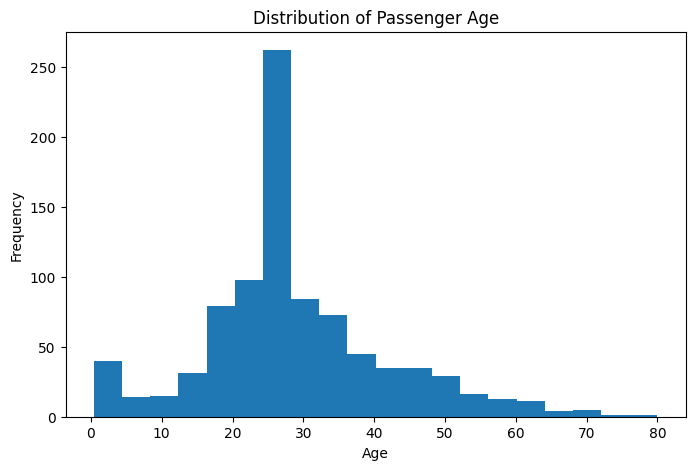

In [17]:
## Step 11: Histogram
##The histogram shows the distribution of passenger ages.
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

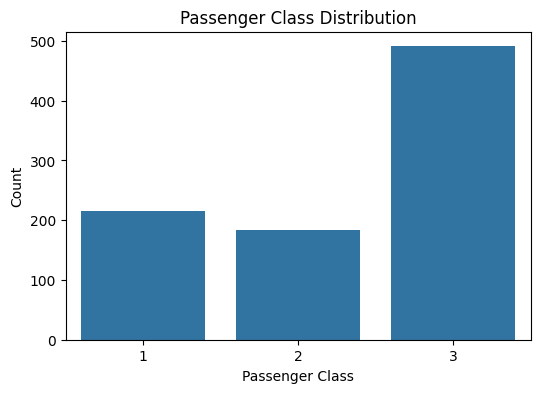

In [18]:
## Step 12: Bar Chart
##The bar chart displays the number of passengers in each passenger class.
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

In [20]:
# Conclusion

##The Titanic dataset was successfully cleaned and analyzed.

##Observations:
##- Missing values were found in Age, Cabin, and Embarked.
##- Age was filled using the median.
##- Embarked was filled using the mode.
##- Cabin was dropped due to a large number of missing values.
##- Duplicate rows were removed.
##- Data types were corrected for categorical columns.
##- Summary statistics were generated.
##- A histogram and bar chart were created to visualize the data.